In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', 20)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [5]:
df.shape

(200, 5)

In [6]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (200, 5)


In [9]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [8]:
print("Column names:", df.columns.tolist())

Column names: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [10]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [11]:
print("Data Types:")
df.dtypes

Data Types:


CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [12]:
print("Statistical Summary of numerical columns:")
df.describe()

Statistical Summary of numerical columns:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [13]:
print("Missing Values in each column:")
df.isna().sum()

Missing Values in each column:


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [14]:
print("Fully duplicated rows in the dataset:", df.duplicated().sum())

Fully duplicated rows in the dataset: 0


In [15]:
print('Unique Customer IDs:', df['CustomerID'].nunique(), "Out  of", df.shape[0], "rows")

Unique Customer IDs: 200 Out  of 200 rows


In [16]:
df.sample()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
106,107,Female,66,63,50


In [19]:
gender_counts = df['Gender'].value_counts()
gender_counts

Gender
Female    112
Male       88
Name: count, dtype: int64

In [28]:
grnder_counts = df['Gender'].value_counts()
gender_pct = (gender_counts/ len(df)* 100).round(1)
print("Gender Distribution:")

for g in gender_counts.index:
    print(f"{g}: {gender_counts[g]} ({gender_pct[g]}%)")

Gender Distribution:
Female: 112 (56.0%)
Male: 88 (44.0%)


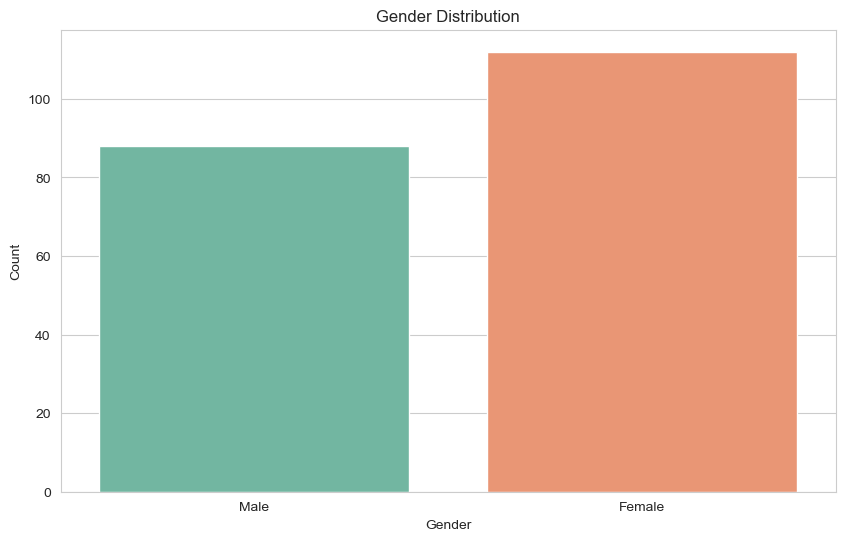

In [33]:
sns.countplot(x='Gender', data=df, hue='Gender', palette='Set2')
plt.title("Gender Distribution")
plt.ylabel('Count')
plt.show()

In [35]:
numerical_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0


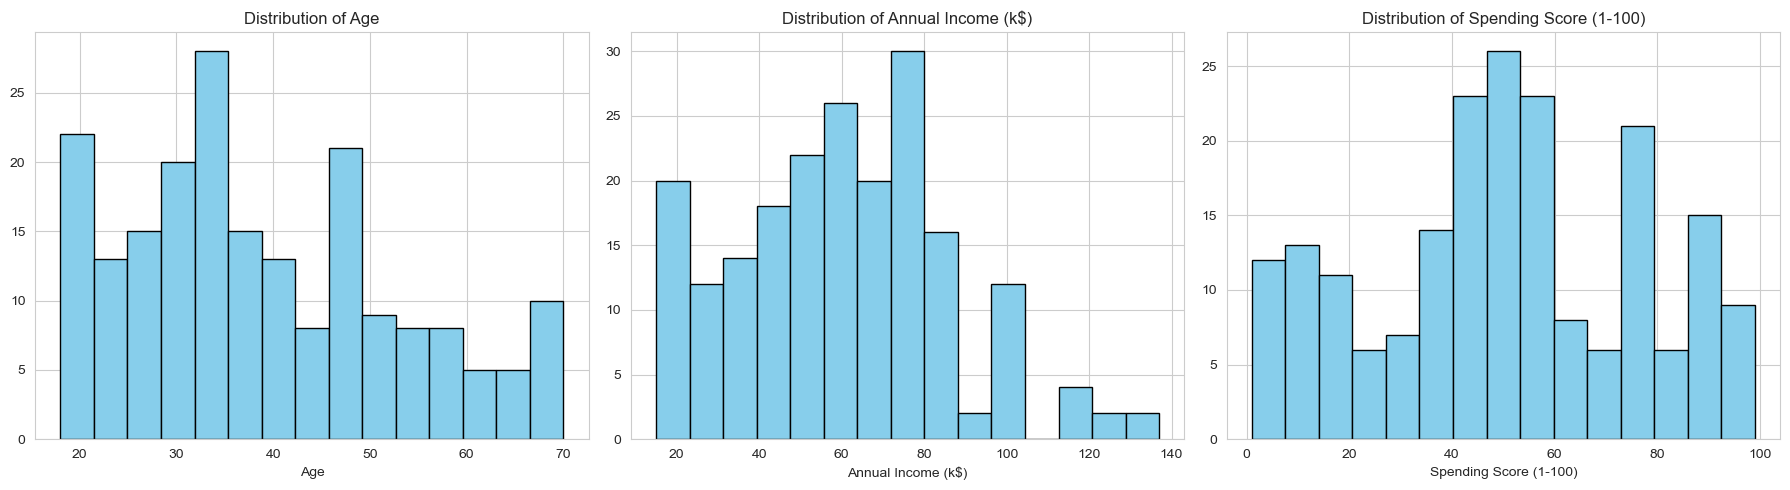

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, numerical_cols):
    ax.hist(df[col], bins=15, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

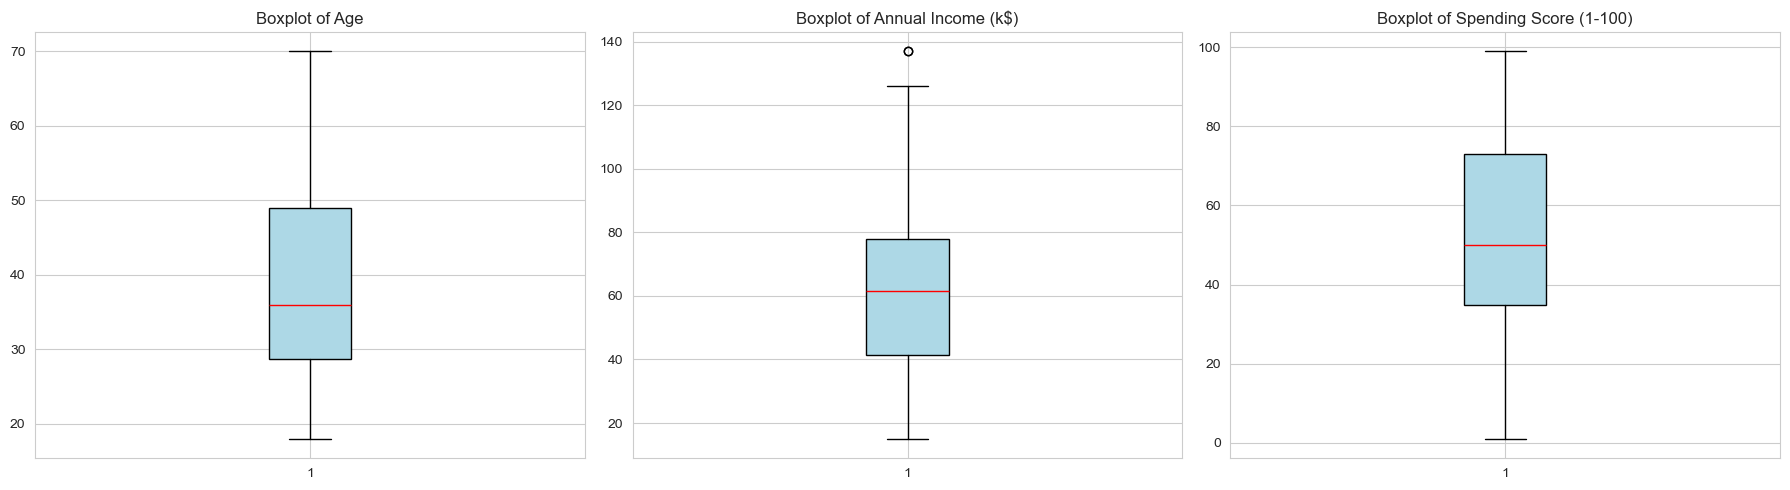

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, numerical_cols):
    ax.boxplot(df[col], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red'), whiskerprops=dict(color='black'), capprops=dict(color='black'))
    ax.set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

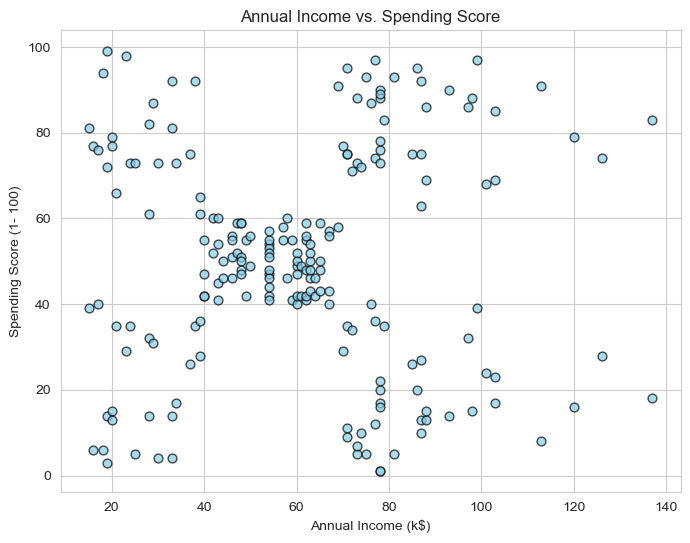

In [39]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c='skyblue', edgecolors='black', s=40, alpha=0.7)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1- 100)')
plt.title("Annual Income vs. Spending Score")
plt.show()

In [40]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [41]:
selected_features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[selected_features].copy()
print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (200, 2)


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


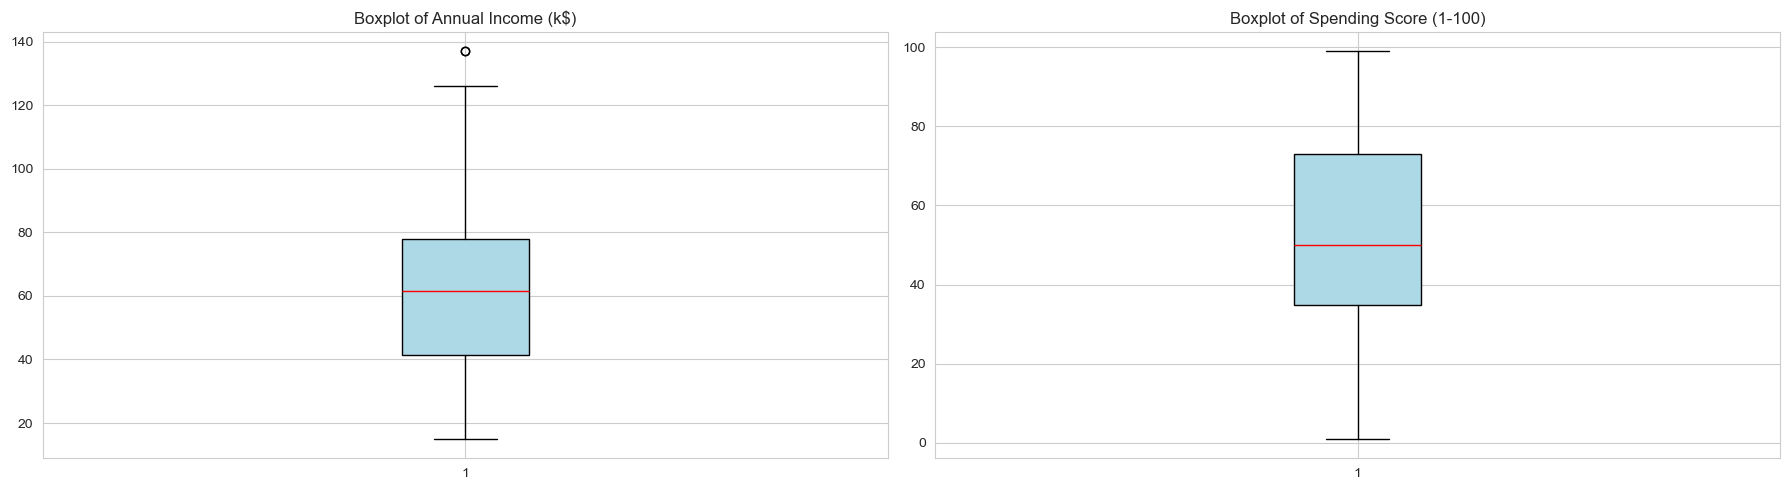

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].boxplot(X['Annual Income (k$)'], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red'), whiskerprops=dict(color='black'), capprops=dict(color='black'))
axes[0].set_title('Boxplot of Annual Income (k$)')
axes[1].boxplot(X['Spending Score (1-100)'], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red'), whiskerprops=dict(color='black'), capprops=dict(color='black'))
axes[1].set_title('Boxplot of Spending Score (1-100)')
plt.tight_layout()
plt.show()

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=selected_features, index=X.index)
X_scaled.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [45]:
X_scaled.describe().loc[['mean','std']].round(3)

,Annual Income (k$),Spending Score (1-100)
mean,-0.000,-0.000
std,1.003,1.003


In [50]:
min_sample_start = 5
print(f'Starting min_samples for DBSCAN: {min_sample_start}')

Starting min_samples for DBSCAN: 5


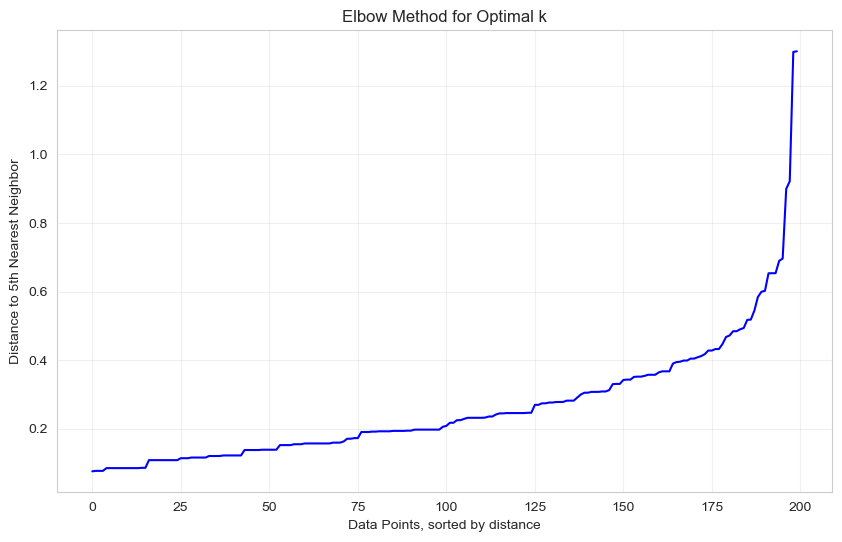

In [51]:
k = min_sample_start

neighbours = NearestNeighbors(n_neighbors=k)
neighbours_fit = neighbours.fit(X_scaled)
distances, indices = neighbours_fit.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances, color='blue')
plt.xlabel('Data Points, sorted by distance')
plt.ylabel(f'Distance to {k}th Nearest Neighbor')
plt.title('Elbow Method for Optimal k')
plt.grid(True, alpha=0.3)
plt.show()

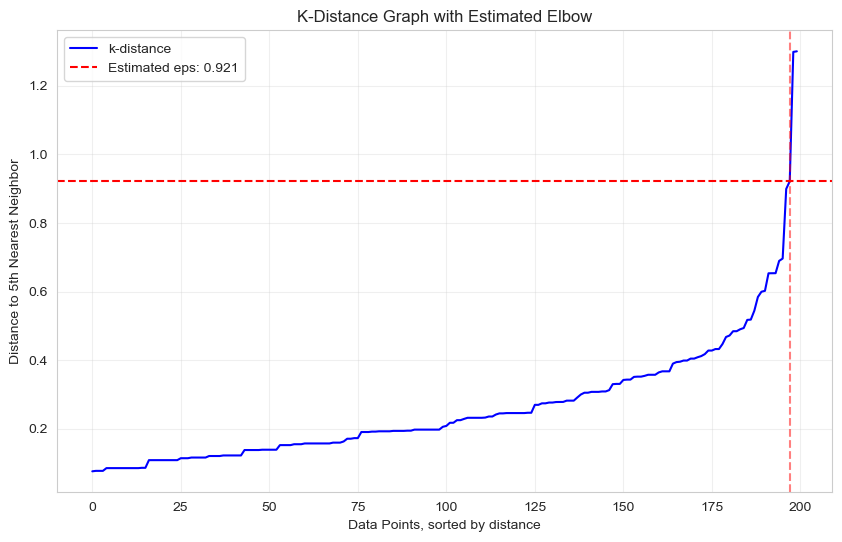

Estimated eps from elbow method: 0.921


In [53]:
diffs = np.diff(k_distances)
elbow_index = np.argmax(diffs)
eps_estimate = round(float(k_distances[elbow_index]), 3)

plt.figure(figsize=(10, 6))
plt.plot(k_distances, color='blue', label='k-distance')
plt.axhline(y=eps_estimate, color='red', linestyle='--', label=f'Estimated eps: {eps_estimate}')
plt.axvline(x=elbow_index, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Data Points, sorted by distance')
plt.ylabel(f'Distance to {k}th Nearest Neighbor')
plt.title('K-Distance Graph with Estimated Elbow')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Estimated eps from elbow method: {eps_estimate}")

In [55]:
initial_eps = eps_estimate
initial_min_samples = min_sample_start

dbscan = DBSCAN(eps=initial_eps, min_samples=initial_min_samples)
cluster_labels =dbscan.fit_predict(X_scaled)

df['Cluster'] = cluster_labels

print("DBSCAN fit complete with eps=", initial_eps, "and min_samples=", initial_min_samples)
print(f'Total customers:{len(df)}')

DBSCAN fit complete with eps= 0.921 and min_samples= 5
Total customers:200


In [56]:
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = int((cluster_labels == -1).sum())
noise_pct = round(n_noise / len(cluster_labels) * 100, 2)

In [57]:
print(f'Number of clusters found: {n_clusters}')
print(f'Number of noise points: {n_noise}')
print(f'percentage of customers classified as noise: {noise_pct}%')

Number of clusters found: 1
Number of noise points: 0
percentage of customers classified as noise: 0.0%


In [58]:
cluster_dist = df['Cluster'].value_counts().sort_index().reset_index()
cluster_dist.columns = ['Cluster', 'Number of Customers']
cluster_dist['Percentage'] = (cluster_dist['Number of Customers'] / len(df) * 100).round(2)
cluster_dist

,Cluster,Number of Customers,Percentage
0,0,200,100.0


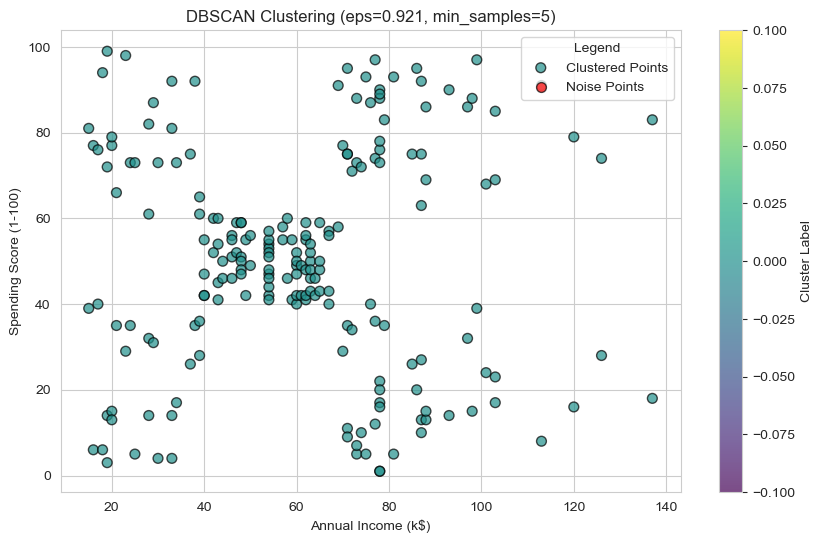

In [60]:
plt.figure(figsize=(10, 6))
clustered = df[df['Cluster'] != -1]
noise = df[df['Cluster'] == -1]

scatter = plt.scatter(clustered['Annual Income (k$)'], clustered['Spending Score (1-100)'], c=clustered['Cluster'], cmap='viridis', edgecolors='black', s=50, alpha=0.7, label='Clustered Points')

plt.scatter(noise['Annual Income (k$)'], noise['Spending Score (1-100)'], c='red', edgecolors='black', s=50, alpha=0.7, label='Noise Points')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'DBSCAN Clustering (eps={initial_eps}, min_samples={initial_min_samples})')
plt.legend(title='Legend', loc='upper right')
plt.colorbar(scatter, label='Cluster Label')
plt.show()

In [61]:
core_mask = np.zeros(len(X_scaled), dtype=bool)
core_mask[dbscan.core_sample_indices_] = True

point_type = np.full(len(X_scaled), 'Border', dtype=object)
point_type[core_mask] = 'Core'
point_type[cluster_labels == -1] = 'Noise'

df['PointType'] = point_type

point_type_counts = df['PointType'].value_counts()
print("Point Type Distribution:")
print(point_type_counts)

print(f"\n({point_type_counts.get('Core', 0)} core points, {point_type_counts.get('Border', 0)} border points, {point_type_counts.get('Noise', 0)} noise points) out of {len(df)} total points.")

Point Type Distribution:
PointType
Core      197
Border      3
Name: count, dtype: int64

(197 core points, 3 border points, 0 noise points) out of 200 total points.


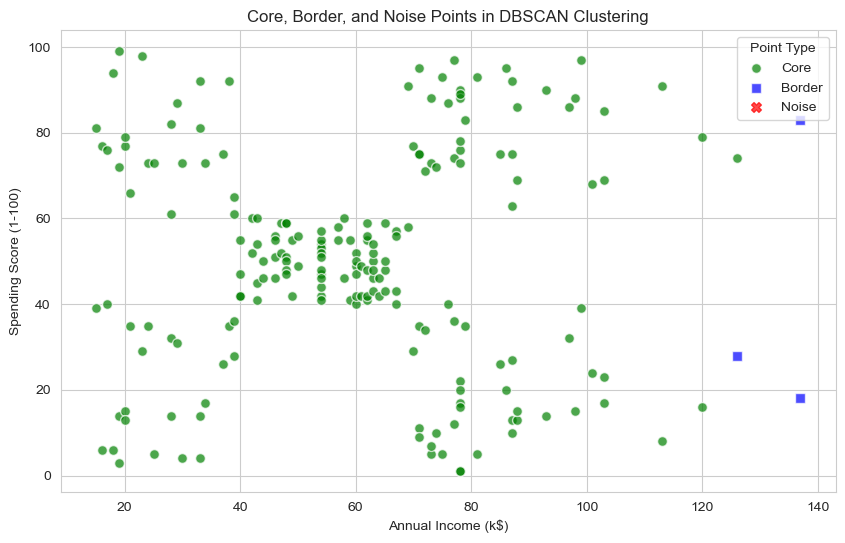

In [62]:
plt.figure(figsize=(10, 6))
type_colors = {'Core': 'green', 'Border': 'blue', 'Noise': 'red'}
type_markers = {'Core': 'o', 'Border': 's', 'Noise': 'X'}

for ptype, color in type_colors.items():
    subset = df[df['PointType'] == ptype]
    plt.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'], c=color, label=ptype, edgecolor='white' if ptype != 'Noise' else None, s=50, alpha=0.7, marker=type_markers[ptype])
    
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Core, Border, and Noise Points in DBSCAN Clustering')
plt.legend(title='Point Type', loc='upper right')
plt.show()

In [63]:
mask_clustered = cluster_labels != -1

if n_clusters >= 2:
    sil_score = silhouette_score(X_scaled[mask_clustered], cluster_labels[mask_clustered])
    print(f"Silhouette Score (noise excluded, {mask_clustered.sum()} points): {sil_score:.4f}")
else:
    sil_score = None
    print('Fewer than 2 clusters found. Silhouette score cannot be computed.')

Fewer than 2 clusters found. Silhouette score cannot be computed.


In [64]:
def run_dbscan(eps_val, min_samples_val, X_data):
    model = DBSCAN(eps=eps_val, min_samples=min_samples_val)
    labels = model.fit_predict(X_data)
    
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    n_ns = int((labels == -1).sum())
    mask = labels != -1
    
    if n_clust >= 2:
        score = round(silhouette_score(X_data[mask], labels[mask]), 4)
    else:
        score = np.nan
        
    return {
        'eps' : eps_val,
        'min_samples' : min_samples_val,
        'clusters' : n_clust,
        'noise_points' : n_ns,
        'noise_pct' : round(n_ns / len(labels) * 100, 2),
        'silhouette' : score
    }
    
eps_candidates = [round(initial_eps * mult, 3) for mult in [0.5, 0.7, 0.85, 1.0, 1.15, 1.3, 1.5]]

eps_experiment_rows = [run_dbscan(eps_val, 5, X_scaled) for eps_val in eps_candidates]
eps_experiment_table = pd.DataFrame(eps_experiment_rows)
eps_experiment_table

,eps,min_samples,clusters,noise_points,noise_pct,silhouette
0,0.461,5,3,11,5.5,0.3536
1,0.645,5,1,5,2.5,NaN
2,0.783,5,1,0,0.0,NaN
3,0.921,5,1,0,0.0,NaN
4,1.059,5,1,0,0.0,NaN
5,1.197,5,1,0,0.0,NaN
6,1.381,5,1,0,0.0,NaN


In [65]:
min_samples_candidates = [3, 5, 7, 10]

ms_experiment_rows = [run_dbscan(initial_eps, ms_val, X_scaled) for ms_val in min_samples_candidates]
ms_experiment_table = pd.DataFrame(ms_experiment_rows)
ms_experiment_table

,eps,min_samples,clusters,noise_points,noise_pct,silhouette
0,0.921,3,1,0,0.0,NaN
1,0.921,5,1,0,0.0,NaN
2,0.921,7,1,0,0.0,NaN
3,0.921,10,1,2,1.0,NaN


In [66]:
all_candidates = pd.concat([eps_experiment_table, ms_experiment_table], ignore_index=True).drop_duplicates()
all_candidates = all_candidates.sort_values(['clusters', 'noise_pct'], ascending=[False, True])
all_candidates

,eps,min_samples,clusters,noise_points,noise_pct,silhouette
0,0.461,5,3,11,5.5,0.3536
2,0.783,5,1,0,0.0,NaN
3,0.921,5,1,0,0.0,NaN
4,1.059,5,1,0,0.0,NaN
5,1.197,5,1,0,0.0,NaN
6,1.381,5,1,0,0.0,NaN
7,0.921,3,1,0,0.0,NaN
9,0.921,7,1,0,0.0,NaN
10,0.921,10,1,2,1.0,NaN
1,0.645,5,1,5,2.5,NaN


In [67]:
usable_candidates = all_candidates[all_candidates['clusters'] > 1].copy()
if len(usable_candidates) > 0:
    usable_candidates = usable_candidates.sort_values(['clusters', 'noise_pct', 'silhouette'], ascending=[False, True, False])
    best_row = usable_candidates.iloc[0]
    final_eps = float(best_row['eps'])
    final_min_samples = int(best_row['min_samples'])
    print('Selected from the tested candidates(more than one cluster, low noise, high silhouette score):')
else:
    final_eps = initial_eps
    final_min_samples = initial_min_samples
    print('No tested candidate produced more than one cluster. Using initial estimates:')
    
print(f"final_eps = {final_eps}, final_min_samples = {final_min_samples}")

final_dbscan = DBSCAN(eps=final_eps, min_samples=final_min_samples)
final_labels = final_dbscan.fit_predict(X_scaled)

df['Cluster'] = final_labels

final_n_clusters = len(set(final_labels)) - (1 if -1 in final_labels else 0)
final_n_noise = int((final_labels == -1).sum())
final_noise_pct = round(final_n_noise / len(final_labels) * 100, 2)

mask_final = final_labels != -1
if final_n_clusters >= 2:
    final_silhouette = round(silhouette_score(X_scaled[mask_final], final_labels[mask_final]), 4)
else:
    final_silhouette = np.nan
    
print(f"Final MODEL: eps={final_eps}, min_samples={final_min_samples}")
print(f"Clusters: {final_n_clusters}")
print(f"Noise Points: {final_n_noise} ({final_noise_pct}%)")
print(f"Silhouette Score (noise excluded): {final_silhouette if not np.isnan(final_silhouette) else 'N/A'}")

Selected from the tested candidates(more than one cluster, low noise, high silhouette score):
final_eps = 0.461, final_min_samples = 5
Final MODEL: eps=0.461, min_samples=5
Clusters: 3
Noise Points: 11 (5.5%)
Silhouette Score (noise excluded): 0.3536
